In [1]:
# Import all of the necessary libraries
import numpy as np
import pandas as pd
import numpy_financial as npf
import matplotlib.pyplot as plt
from collections import namedtuple
from datetime import date, timedelta

In [2]:
# Define loan parameters
original_balance = 255000
coupon = 0.05
term = 240

# Create payment schedule periods
periods = range(1, term+1)

# Calculate interest and principal payments
interest_payment = npf.ipmt(
    rate=coupon / 12, per=periods, nper=term, pv=-original_balance)
principal_payment = npf.ppmt(
    rate=coupon / 12, per=periods, nper=term, pv=-original_balance)

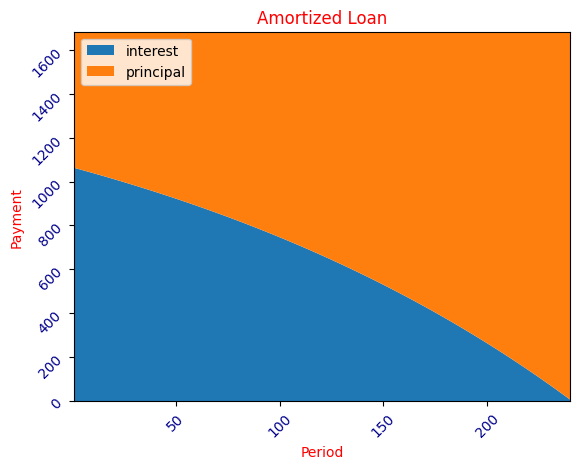

In [3]:
# Create a stacked area plot showing interest and principal payments over time
plt.stackplot(periods, interest_payment, principal_payment,
              labels=['interest', 'principal'])
plt.legend(loc='upper left')
plt.xticks(rotation = 45, color = 'darkblue')
plt.yticks(rotation = 45, color = 'darkblue')
plt.xlabel('Period', color = 'red')
plt.ylabel('Payment', color = 'red')
plt.title('Amortized Loan', color = 'red')
plt.margins(0, 0)
plt.show()

In [4]:
# Set the display format for floating-point numbers to two decimal places
pd.options.display.float_format = '{:,.2f}'.format

# Create a dictionary called 'cash' to store interest and principal payments
cash = {'Interest': interest_payment, 'Principal': principal_payment}

# Create a Pandas DataFrame called 'ct' using the 'cash' dictionary as data and 'periods' as the index
ct = pd.DataFrame(data=cash, index=periods)

# Calculate the total payment by adding interest and principal payments and store it in a new 'Payment' column
ct['Payment'] = ct['Interest'] + ct['Principal']

# Calculate the ending balance by subtracting the cumulative sum of principal payments from the original balance
ct['Ending Balance'] = original_balance - ct['Principal'].cumsum()

# Calculate the beginning balance for each period.
ct['Beginning Balance'] = [original_balance] + list(ct['Ending Balance'])[:-1]

# Reorder the columns in the DataFrame to a more logical order
ct = ct[['Beginning Balance', 'Payment', 'Interest','Principal', 'Ending Balance']]

# Observe first 10 rows of the DataFrame
ct.head(10)

,Beginning Balance,Payment,Interest,Principal,Ending Balance
1,"255,000.00","1,682.89","1,062.50",620.39,"254,379.61"
2,"254,379.61","1,682.89","1,059.92",622.97,"253,756.64"
3,"253,756.64","1,682.89","1,057.32",625.57,"253,131.07"
4,"253,131.07","1,682.89","1,054.71",628.17,"252,502.90"
5,"252,502.90","1,682.89","1,052.10",630.79,"251,872.11"
6,"251,872.11","1,682.89","1,049.47",633.42,"251,238.69"
7,"251,238.69","1,682.89","1,046.83",636.06,"250,602.63"
8,"250,602.63","1,682.89","1,044.18",638.71,"249,963.92"
9,"249,963.92","1,682.89","1,041.52",641.37,"249,322.55"
10,"249,322.55","1,682.89","1,038.84",644.04,"248,678.50"


In [5]:
# Assuming the loan starts on January 1, 2024
start_date = date(2024, 1, 1)

# Generate a date range for the loan term
ct['Date'] = [start_date + timedelta(days=30 * i) for i in range(term)]

# Set 'Date' as the index for time series analysis
ct.set_index('Date', inplace=True)

# Reorder the columns in the DataFrame
ct = ct[['Beginning Balance', 'Payment', 'Interest', 'Principal', 'Ending Balance']]

# Display the first 10 rows of the DataFrame
ct.head(10)

,Beginning Balance,Payment,Interest,Principal,Ending Balance
Date,,,,,
2024-01-01,"255,000.00","1,682.89","1,062.50",620.39,"254,379.61"
2024-01-31,"254,379.61","1,682.89","1,059.92",622.97,"253,756.64"
2024-03-01,"253,756.64","1,682.89","1,057.32",625.57,"253,131.07"
2024-03-31,"253,131.07","1,682.89","1,054.71",628.17,"252,502.90"
2024-04-30,"252,502.90","1,682.89","1,052.10",630.79,"251,872.11"
2024-05-30,"251,872.11","1,682.89","1,049.47",633.42,"251,238.69"
2024-06-29,"251,238.69","1,682.89","1,046.83",636.06,"250,602.63"
2024-07-29,"250,602.63","1,682.89","1,044.18",638.71,"249,963.92"
2024-08-28,"249,963.92","1,682.89","1,041.52",641.37,"249,322.55"


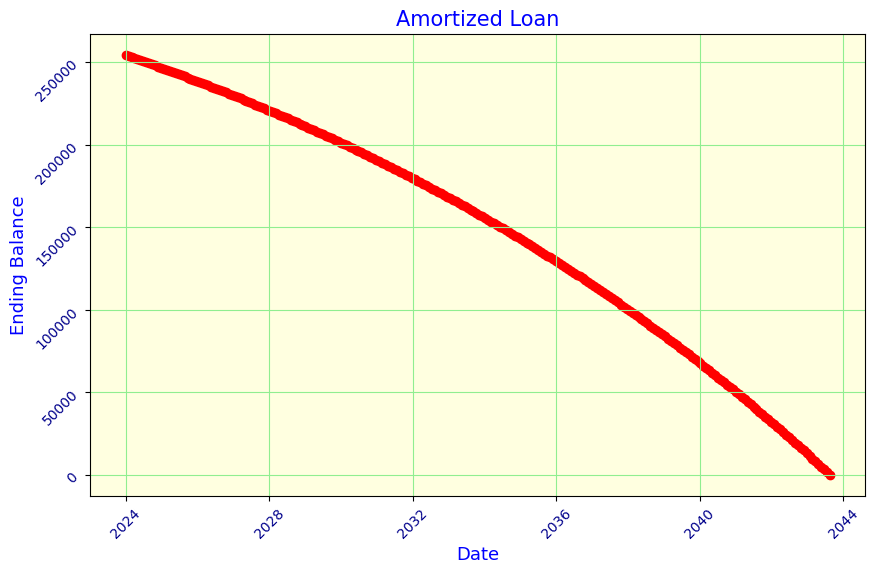

In [6]:
# Plot the End Balance of the Amortized Loan
plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('lightyellow')
plt.scatter(ct.index, ct['Ending Balance'], color = 'red')
plt.xticks(rotation = 45, color = 'darkblue')
plt.yticks(rotation = 45, color = 'darkblue')
plt.xlabel('Date', color = 'blue',fontsize=13)
plt.ylabel('Ending Balance', color = 'blue',fontsize=13)
plt.title('Amortized Loan', color = 'blue',fontsize=15)
plt.grid(True, color = 'lightgreen')
plt.show()

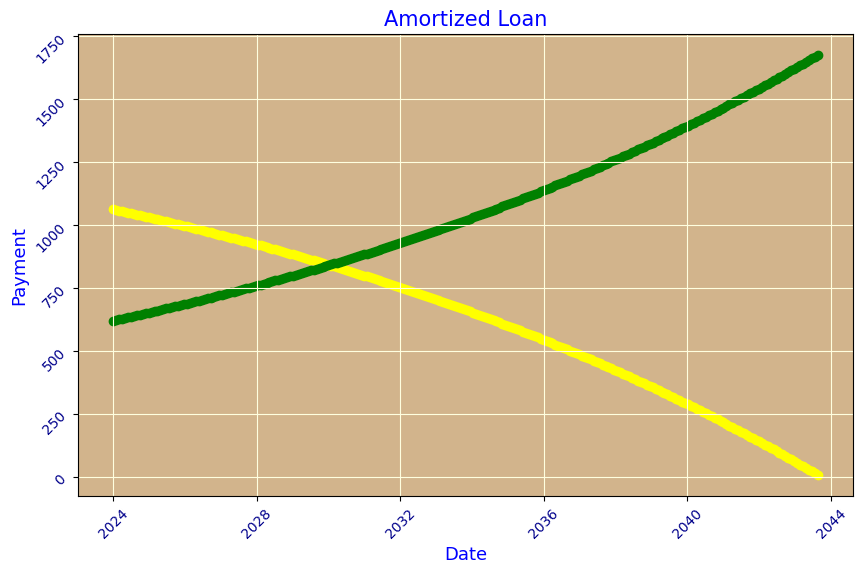

In [7]:
# Plot the correlation between the interest rate and principal of the amortized loan
plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('tan')
plt.scatter(ct.index, ct['Interest'], color = 'yellow')
plt.scatter(ct.index, ct['Principal'], color = 'green')
plt.xlabel('Date', color = 'blue', fontsize=13)
plt.ylabel('Payment', color = 'blue', fontsize=13)
plt.xticks(rotation = 45, color = 'darkblue')
plt.yticks(rotation = 45, color = 'darkblue')
plt.title('Amortized Loan', color = 'blue',fontsize=15)
plt.grid(True, color = 'lightyellow')
plt.show()